In [45]:
!pip install pybullet

In [ ]:

#  C.1: Generate the PRR Robot URDF (Unified Robot Description Format)

import os

# ------------------------------------------------------------------------------
# Robot Physical Parameters & Kinematic Constraints
# ------------------------------------------------------------------------------
# Prismatic joint (Link 1) stroke limits (in meters)
Q1_MIN = 0.0
Q1_MAX = 0.50

# Link lengths derived from the Denavit-Hartenberg (DH) parameters (in meters)
D0 = 0.70  # Base to Link 1 initial height offset
L2 = 0.40  # Length of the second link (revolute shoulder)
L3 = 0.30  # Length of the third link (revolute elbow)

# ------------------------------------------------------------------------------
# URDF XML Definition
# ------------------------------------------------------------------------------
# The base_link radius is set to 0.04m to prevent visual occlusion of the
# inspection workspace, while preserving the mathematical coordinate frames.
URDF_TEXT = f"""\
<?xml version="1.0"?>
<robot name="prr_robot">

  <link name="base_link">
    <visual>
      <geometry><cylinder radius="0.04" length="0.20"/></geometry>
      <origin xyz="0 0 0.10"/>
      <material name="dark"><color rgba="0.15 0.15 0.17 1"/></material>
    </visual>
    <collision>
      <geometry><cylinder radius="0.04" length="0.20"/></geometry>
      <origin xyz="0 0 0.10"/>
    </collision>
    <inertial>
      <mass value="10"/>
      <inertia ixx="0.2" ixy="0" ixz="0" iyy="0.2" iyz="0" izz="0.2"/>
    </inertial>
  </link>

  <link name="link1">
    <visual>
      <geometry><box size="0.08 0.08 0.50"/></geometry>
      <origin xyz="0 0 0.25"/>
      <material name="blue"><color rgba="0.20 0.45 0.85 1"/></material>
    </visual>
    <collision>
      <geometry><box size="0.08 0.08 0.50"/></geometry>
      <origin xyz="0 0 0.25"/>
    </collision>
    <inertial>
      <mass value="2.5"/>
      <origin xyz="0 0 0.25"/>
      <inertia ixx="0.06" ixy="0" ixz="0" iyy="0.06" iyz="0" izz="0.01"/>
    </inertial>
  </link>

  <joint name="j1_prismatic" type="prismatic">
    <parent link="base_link"/>
    <child  link="link1"/>
    <origin xyz="0 0 0.20"/>
    <axis   xyz="0 0 1"/>
    <limit  lower="{Q1_MIN}" upper="{Q1_MAX}" effort="200" velocity="1"/>
  </joint>

  <link name="link2">
    <visual>
      <geometry><box size="{L2} 0.07 0.07"/></geometry>
      <origin xyz="{L2/2} 0 0"/>
      <material name="orange"><color rgba="0.95 0.55 0.10 1"/></material>
    </visual>
    <collision>
      <geometry><box size="{L2} 0.07 0.07"/></geometry>
      <origin xyz="{L2/2} 0 0"/>
    </collision>
    <inertial>
      <mass value="1.0"/>
      <origin xyz="{L2/2} 0 0"/>
      <inertia ixx="0.005" ixy="0" ixz="0" iyy="0.030" iyz="0" izz="0.030"/>
    </inertial>
  </link>

  <joint name="j2_revolute" type="continuous">
    <parent link="link1"/>
    <child  link="link2"/>
    <origin xyz="0 0 0.50"/>
    <axis   xyz="0 0 1"/>
  </joint>

  <link name="link3">
    <visual>
      <geometry><box size="{L3} 0.06 0.06"/></geometry>
      <origin xyz="{L3/2} 0 0"/>
      <material name="green"><color rgba="0.20 0.75 0.30 1"/></material>
    </visual>
    <collision>
      <geometry><box size="{L3} 0.06 0.06"/></geometry>
      <origin xyz="{L3/2} 0 0"/>
    </collision>
    <inertial>
      <mass value="0.7"/>
      <origin xyz="{L3/2} 0 0"/>
      <inertia ixx="0.003" ixy="0" ixz="0" iyy="0.020" iyz="0" izz="0.020"/>
    </inertial>
  </link>

  <joint name="j3_revolute" type="continuous">
    <parent link="link2"/>
    <child  link="link3"/>
    <origin xyz="{L2} 0 0"/>
    <axis   xyz="0 0 1"/>
  </joint>

  <link name="ee">
    <visual>
      <geometry><sphere radius="0.025"/></geometry>
      <material name="yellow"><color rgba="1.0 0.85 0.10 1"/></material>
    </visual>
    <collision>
      <geometry><sphere radius="0.025"/></geometry>
    </collision>
    <inertial>
      <mass value="0.05"/>
      <inertia ixx="1e-5" ixy="0" ixz="0" iyy="1e-5" iyz="0" izz="1e-5"/>
    </inertial>
  </link>

  <joint name="ee_fixed" type="fixed">
    <parent link="link3"/>
    <child  link="ee"/>
    <origin xyz="{L3} 0 0"/>
  </joint>

</robot>
"""

# ------------------------------------------------------------------------------
# Export URDF File
# ------------------------------------------------------------------------------
URDF_PATH = "/content/prr_robot.urdf"

# Write the URDF string to the local filesystem
with open(URDF_PATH, "w") as f:
    f.write(URDF_TEXT)

# Print confirmation logs
print(f"[INFO] Success: URDF file generated and saved to '{URDF_PATH}'.")
print(f"[INFO] Payload size: {len(URDF_TEXT)} bytes.")

[INFO] Success: URDF file generated and saved to '/content/prr_robot.urdf'.
[INFO] Payload size: 3154 bytes.


[INFO] PyBullet environment initialized successfully. Robot and targets are set.

Target   | Simulated EE (x, y, z)              | Math EE (x, y, z)                   | Error (mm)
-----------------------------------------------------------------------------------------------
red      | (0.6110, -0.3416, 0.7500)           | (0.6110, -0.3416, 0.7500)           | 0.000000
red      | (0.6249, 0.3155, 0.7500)            | (0.6249, 0.3155, 0.7500)            | 0.000000
green    | (-0.1721, 0.6785, 0.7500)           | (-0.1721, 0.6785, 0.7500)           | 0.000000
green    | (-0.6340, 0.2967, 0.7500)           | (-0.6340, 0.2967, 0.7500)           | 0.000000
blue     | (-0.5422, -0.4428, 0.7500)          | (-0.5422, -0.4428, 0.7500)          | 0.000000


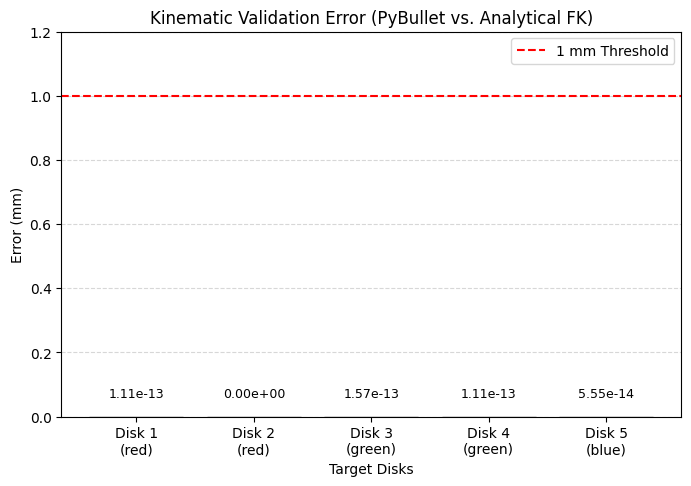

In [ ]:

#  C.2 & C.3: Workcell Initialization & Kinematic Validation

import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Static Parameters & Initial Target Data
# ------------------------------------------------------------------------------
D0, L2, L3 = 0.70, 0.40, 0.30
URDF_PATH = "/content/prr_robot.urdf"  # Generated in Task C.1

# Ground-truth/detected data from the Vision Pipeline (Part A)
my_data = [
    {'color': 'red',   'xy': (0.186, -0.104), 'rgb': [1, 0, 0, 1]},
    {'color': 'red',   'xy': (0.103, 0.052),  'rgb': [1, 0, 0, 1]},
    {'color': 'green', 'xy': (-0.053, 0.209), 'rgb': [0, 1, 0, 1]},
    {'color': 'green', 'xy': (-0.156, 0.073), 'rgb': [0, 1, 0, 1]},
    {'color': 'blue',  'xy': (-0.229, -0.187),'rgb': [0, 0, 1, 1]}
]

def fk_math(q1, q2, q3):
    """
    Analytical Forward Kinematics (FK) derived in Part B.
    Returns the (x, y, z) coordinates of the end-effector.
    """
    x = np.cos(q2) * (L2 + L3 * np.cos(q3)) - L3 * np.sin(q2) * np.sin(q3)
    y = np.sin(q2) * (L2 + L3 * np.cos(q3)) + L3 * np.cos(q2) * np.sin(q3)
    z = D0 + q1
    return np.array([x, y, z])

# ------------------------------------------------------------------------------
# 2. PyBullet Environment Setup (Task C.2)
# ------------------------------------------------------------------------------
# Connect to the physics engine in DIRECT mode (no GUI, ideal for Colab)
client_id = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)

# Load the workspace (ground plane) and the custom PRR robot
plane_id = p.loadURDF("plane.urdf", [0, 0, 0])
robot_id = p.loadURDF(URDF_PATH, basePosition=[0, 0, 0], useFixedBase=True)

# Dynamically extract joint and link indices based on URDF naming
joint_indices = {}
ee_link_index = -1

for i in range(p.getNumJoints(robot_id)):
    info = p.getJointInfo(robot_id, i)
    joint_name = info[1].decode('utf-8')
    link_name = info[12].decode('utf-8')

    if "j1" in joint_name: joint_indices['q1'] = i
    if "j2" in joint_name: joint_indices['q2'] = i
    if "j3" in joint_name: joint_indices['q3'] = i
    if "ee" in link_name:  ee_link_index = i

# Spawn cylindrical markers to represent the target disks on the table
disk_ids = []
for disk in my_data:
    tx, ty = disk['xy']
    rgba = disk['rgb']

    visual_shape = p.createVisualShape(
        shapeType=p.GEOM_CYLINDER,
        radius=0.02,
        length=0.005,
        rgbaColor=rgba
    )

    body_id = p.createMultiBody(
        baseMass=0,
        baseVisualShapeIndex=visual_shape,
        basePosition=[tx, ty, 0.0025]
    )
    disk_ids.append(body_id)

print("[INFO] PyBullet environment initialized successfully. Robot and targets are set.\n")

# ------------------------------------------------------------------------------
# 3. Kinematic Validation (Task C.3)
# ------------------------------------------------------------------------------
def simple_ik(tx, ty):
    """
    Dummy Inverse Kinematics for preliminary testing.
    Assumes a fully extended arm (q3 = 0.0) aligned with the target.
    """
    q2 = np.arctan2(ty, tx)
    q3 = 0.0
    q1 = 0.05  # Safe clearance height (z_safe)
    return q1, q2, q3

errors = []
print(f"{'Target':<8} | {'Simulated EE (x, y, z)':<35} | {'Math EE (x, y, z)':<35} | {'Error (mm)':<10}")
print("-" * 95)

# Iterate through targets, apply joints, read simulation state, and compare
for i, disk in enumerate(my_data):
    tx, ty = disk['xy']

    # 1. Compute target joint angles
    q1, q2, q3 = simple_ik(tx, ty)

    # 2. Apply joint angles to the simulated robot
    p.resetJointState(robot_id, joint_indices['q1'], q1)
    p.resetJointState(robot_id, joint_indices['q2'], q2)
    p.resetJointState(robot_id, joint_indices['q3'], q3)

    # 3. Step the physics engine to update the kinematic tree
    p.stepSimulation()

    # 4. Read the actual End-Effector position from the simulator
    ee_state = p.getLinkState(robot_id, ee_link_index)
    pos_sim = np.array(ee_state[0])

    # 5. Compute the expected position using analytical equations
    pos_math = fk_math(q1, q2, q3)

    # 6. Calculate Euclidean error in millimeters
    error_m = np.linalg.norm(pos_sim - pos_math)
    error_mm = error_m * 1000.0
    errors.append(error_mm)

    # Print formatted comparison
    sim_str = f"({pos_sim[0]:.4f}, {pos_sim[1]:.4f}, {pos_sim[2]:.4f})"
    math_str = f"({pos_math[0]:.4f}, {pos_math[1]:.4f}, {pos_math[2]:.4f})"
    print(f"{disk['color']:<8} | {sim_str:<35} | {math_str:<35} | {error_mm:.6f}")

# Disconnect physics client to free up resources
p.disconnect()

# ------------------------------------------------------------------------------
# 4. Data Visualization: Kinematic Validation Error
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
colors = [d['color'] for d in my_data]

# Generate bar chart
bars = plt.bar(range(len(my_data)), errors, color=colors, edgecolor='black', alpha=0.7)

# Overlay the 1mm tolerance threshold required by the assignment
plt.axhline(y=1.0, color='r', linestyle='--', label='1 mm Threshold')

# Formatting
plt.title('Kinematic Validation Error (PyBullet vs. Analytical FK)')
plt.ylabel('Error (mm)')
plt.xlabel('Target Disks')
plt.xticks(range(len(my_data)), [f"Disk {i+1}\n({d['color']})" for i, d in enumerate(my_data)])
plt.ylim(0, max(max(errors) * 1.5, 1.2))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate bars with exact error values (scientific notation for tiny floats)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2e}', ha='center', va='bottom', fontsize=9)

plt.show()

[INFO] Rendering the initial (flawed) animation with self-collision...
[SUCCESS] Flawed animation saved to: /content/inspection_process_flawed.gif


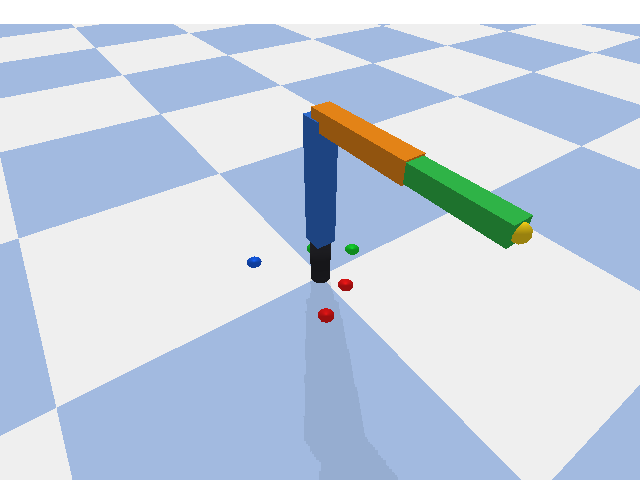

In [ ]:

# C.4 (Part 1): Initial Animation Simulation
# Demonstrating the "Self-Collision" / "Joint Wrap-around" Issue

import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import display, Image

# ------------------------------------------------------------------------------
# 1. Target Data Definition
# ------------------------------------------------------------------------------
# Ground-truth/detected data from the Vision Pipeline
my_data = [
    {'color': 'red',   'xy': (0.186, -0.104), 'rgb': [1, 0.1, 0.1, 1]},
    {'color': 'red',   'xy': (0.103, 0.052),  'rgb': [1, 0.1, 0.1, 1]},
    {'color': 'green', 'xy': (-0.053, 0.209), 'rgb': [0.1, 0.9, 0.2, 1]},
    {'color': 'green', 'xy': (-0.156, 0.073), 'rgb': [0.1, 0.9, 0.2, 1]},
    {'color': 'blue',  'xy': (-0.229, -0.187),'rgb': [0.1, 0.4, 1.0, 1]}
]

# ------------------------------------------------------------------------------
# 2. Kinematic Algorithms (Flawed Version)
# ------------------------------------------------------------------------------
def find_best_ik_smart(tx, ty, prev_q=(0, 0)):
    """
    Grid search algorithm minimizing angular jumps.
    NOTE: This version allows the elbow joint to cross the 180-degree mark,
    which physically translates to the robotic arm passing through itself.
    """
    q2_samples = np.linspace(-np.pi, np.pi, 150)
    q3_samples = np.linspace(-np.pi, np.pi, 150)
    Q2, Q3 = np.meshgrid(q2_samples, q3_samples)

    # Forward kinematics calculation for the grid
    X = L2 * np.cos(Q2) + L3 * np.cos(Q2 + Q3)
    Y = L2 * np.sin(Q2) + L3 * np.sin(Q2 + Q3)
    DIST = np.sqrt((X - tx)**2 + (Y - ty)**2)

    # Penalty for sudden angular jumps (allows circular wrap-around)
    D2 = (Q2 - prev_q[0] + np.pi) % (2 * np.pi) - np.pi
    D3 = (Q3 - prev_q[1] + np.pi) % (2 * np.pi) - np.pi
    SCORE = DIST * 1000 + (np.abs(D2) + np.abs(D3))

    min_idx = np.unravel_index(np.argmin(SCORE), SCORE.shape)
    return Q2[min_idx], Q3[min_idx]

def interpolate_shortest_path(start_q, end_q, steps):
    """
    Linear interpolation on a circle.
    Finds the shortest mathematical path, but causes self-collision in reality.
    """
    path = []
    for i in range(steps):
        t = i / float(steps - 1)
        q1 = start_q[0] + t * (end_q[0] - start_q[0])
        q2 = start_q[1] + t * ((end_q[1] - start_q[1] + np.pi) % (2 * np.pi) - np.pi)
        q3 = start_q[2] + t * ((end_q[2] - start_q[2] + np.pi) % (2 * np.pi) - np.pi)
        path.append([q1, q2, q3])
    return path

# ------------------------------------------------------------------------------
# 3. PyBullet Environment Setup
# ------------------------------------------------------------------------------
# Connect to the physics engine
p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.loadURDF("plane.urdf", [0, 0, 0])

# Load the previously generated URDF (Ensure URDF_PATH is defined prior to this)
robot_id = p.loadURDF(URDF_PATH, basePosition=[0, 0, 0], useFixedBase=True)

# Extract joint and link indices
joint_indices = {}
ee_link_index = -1
for i in range(p.getNumJoints(robot_id)):
    info = p.getJointInfo(robot_id, i)
    j_name = info[1].decode('utf-8')
    if "j1" in j_name: joint_indices['q1'] = i
    if "j2" in j_name: joint_indices['q2'] = i
    if "j3" in j_name: joint_indices['q3'] = i
    if "ee" in info[12].decode('utf-8'): ee_link_index = i

# Spawn cylindrical markers representing target disks
for disk in my_data:
    v_shape = p.createVisualShape(p.GEOM_CYLINDER, radius=0.03, length=0.01, rgbaColor=disk['rgb'])
    p.createMultiBody(baseMass=0, baseVisualShapeIndex=v_shape, basePosition=[disk['xy'][0], disk['xy'][1], 0.005])

# ------------------------------------------------------------------------------
# 4. Waypoint Generation
# ------------------------------------------------------------------------------
home_pose = np.array([0.0, 0.0, 0.0])
waypoints = [home_pose]
current_q = (0.0, 0.0)
q1_safe = 0.05

for disk in my_data:
    q2, q3 = find_best_ik_smart(disk['xy'][0], disk['xy'][1], prev_q=current_q)
    current_q = (q2, q3)
    waypoints.append(np.array([q1_safe, q2, q3]))

waypoints.append(home_pose)

# ------------------------------------------------------------------------------
# 5. Camera Setup & Rendering Loop
# ------------------------------------------------------------------------------
WIDTH, HEIGHT = 640, 480
view_matrix = p.computeViewMatrixFromYawPitchRoll([0.0, 0.0, 0.2], 1.6, 55, -40, 0, 2)
proj_matrix = p.computeProjectionMatrixFOV(60, WIDTH / HEIGHT, 0.02, 5.0)

frames = []
STEPS_PER_SEGMENT = 16
DWELL_FRAMES = 10

print("[INFO] Rendering the initial (flawed) animation with self-collision...")

for i in range(len(waypoints) - 1):
    path = interpolate_shortest_path(waypoints[i], waypoints[i+1], STEPS_PER_SEGMENT)

    for step, q_state in enumerate(path):
        # Apply joint states
        p.resetJointState(robot_id, joint_indices['q1'], q_state[0])
        p.resetJointState(robot_id, joint_indices['q2'], q_state[1])
        p.resetJointState(robot_id, joint_indices['q3'], q_state[2])
        p.stepSimulation()

        # Capture frame
        img = p.getCameraImage(WIDTH, HEIGHT, view_matrix, proj_matrix, renderer=p.ER_TINY_RENDERER, shadow=1)
        frames.append(np.reshape(img[2], (HEIGHT, WIDTH, 4))[:, :, :3].astype(np.uint8))

        # Draw inspection laser during dwell time
        if step == STEPS_PER_SEGMENT - 1 and i < len(waypoints) - 2:
            ee_pos = p.getLinkState(robot_id, ee_link_index)[0]
            laser = p.addUserDebugLine(ee_pos, [ee_pos[0], ee_pos[1], 0.0], lineColorRGB=[1, 0, 0], lineWidth=3)

            for _ in range(DWELL_FRAMES):
                img = p.getCameraImage(WIDTH, HEIGHT, view_matrix, proj_matrix, renderer=p.ER_TINY_RENDERER, shadow=1)
                frames.append(np.reshape(img[2], (HEIGHT, WIDTH, 4))[:, :, :3].astype(np.uint8))

            p.removeUserDebugItem(laser)

# Disconnect the simulation environment
p.disconnect()

# ------------------------------------------------------------------------------
# 6. Save and Display GIF
# ------------------------------------------------------------------------------
GIF_PATH = "/content/inspection_process_flawed.gif"
imageio.mimsave(GIF_PATH, frames, fps=15, loop=0)

print(f"[SUCCESS] Flawed animation saved to: {GIF_PATH}")
display(Image(filename=GIF_PATH))

In [ ]:


# C.4 (Part 2): Generate the Corrected & Safe PRR Robot URDF
# Resolving Self-Collision via Revolute Joints and Angle Limits
import os

# ------------------------------------------------------------------------------
# Robot Physical Parameters & Kinematic Constraints
# ------------------------------------------------------------------------------
# Prismatic joint (Link 1) stroke limits (in meters)
Q1_MIN, Q1_MAX = 0.0, 0.50

# Link lengths derived from the Denavit-Hartenberg (DH) parameters (in meters)
D0 = 0.70  # Base to Link 1 initial height offset
L2 = 0.40  # Length of the second link (revolute shoulder)
L3 = 0.30  # Length of the third link (revolute elbow)

# ------------------------------------------------------------------------------
# Safe URDF XML Definition
# ------------------------------------------------------------------------------
# Engineering Updates in this version:
# 1. Base link radius reduced to 0.04m to prevent visual occlusion of disks.
# 2. Joint 'j2_revolute' and 'j3_revolute' changed from 'continuous' to 'revolute'.
# 3. Strict <limit> tags added to 'j3_revolute' to prevent the forearm from
#    folding into the previous link (avoiding self-collision).
URDF_TEXT = f"""\
<?xml version="1.0"?>
<robot name="prr_robot">
  <link name="base_link">
    <visual>
      <geometry><cylinder radius="0.04" length="0.20"/></geometry>
      <origin xyz="0 0 0.10"/>
      <material name="dark"><color rgba="0.15 0.15 0.17 1"/></material>
    </visual>
  </link>

  <link name="link1">
    <visual>
      <geometry><box size="0.08 0.08 0.50"/></geometry>
      <origin xyz="0 0 0.25"/>
      <material name="blue"><color rgba="0.20 0.45 0.85 1"/></material>
    </visual>
  </link>

  <joint name="j1_prismatic" type="prismatic">
    <parent link="base_link"/>
    <child  link="link1"/>
    <origin xyz="0 0 0.20"/>
    <axis   xyz="0 0 1"/>
    <limit  lower="{Q1_MIN}" upper="{Q1_MAX}" effort="200" velocity="1"/>
  </joint>

  <link name="link2">
    <visual>
      <geometry><box size="{L2} 0.07 0.07"/></geometry>
      <origin xyz="{L2/2} 0 0"/>
      <material name="orange"><color rgba="0.95 0.55 0.10 1"/></material>
    </visual>
  </link>

  <joint name="j2_revolute" type="revolute">
    <parent link="link1"/>
    <child  link="link2"/>
    <origin xyz="0 0 0.50"/>
    <axis   xyz="0 0 1"/>
    <limit lower="-3.14" upper="3.14" effort="200" velocity="2"/>
  </joint>

  <link name="link3">
    <visual>
      <geometry><box size="{L3} 0.06 0.06"/></geometry>
      <origin xyz="{L3/2} 0 0"/>
      <material name="green"><color rgba="0.20 0.75 0.30 1"/></material>
    </visual>
  </link>

  <joint name="j3_revolute" type="revolute">
    <parent link="link2"/>
    <child  link="link3"/>
    <origin xyz="{L2} 0 0"/>
    <axis   xyz="0 0 1"/>
    <limit lower="-3.05" upper="3.05" effort="200" velocity="2"/>
  </joint>

  <link name="ee">
    <visual>
      <geometry><sphere radius="0.025"/></geometry>
      <material name="yellow"><color rgba="1.0 0.85 0.10 1"/></material>
    </visual>
  </link>

  <joint name="ee_fixed" type="fixed">
    <parent link="link3"/>
    <child  link="ee"/>
    <origin xyz="{L3} 0 0"/>
  </joint>
</robot>
"""

# ------------------------------------------------------------------------------
# Export URDF File
# ------------------------------------------------------------------------------
URDF_PATH = "prr_robot.urdf"

# Write the URDF string to the local filesystem
with open(URDF_PATH, "w") as f:
    f.write(URDF_TEXT)

# Print confirmation logs
print(f"[INFO] Success: Collision-free URDF file generated and saved to '{URDF_PATH}'.")
print(f"[INFO] Payload size: {len(URDF_TEXT)} bytes.")

[INFO] Success: Collision-free URDF file generated and saved to 'prr_robot.urdf'.
[INFO] Payload size: 1957 bytes.


[INFO] Rendering the safe animation with dynamic physical laser...
[SUCCESS] Simulation complete. GIF saved to: inspection_process_laser.gif


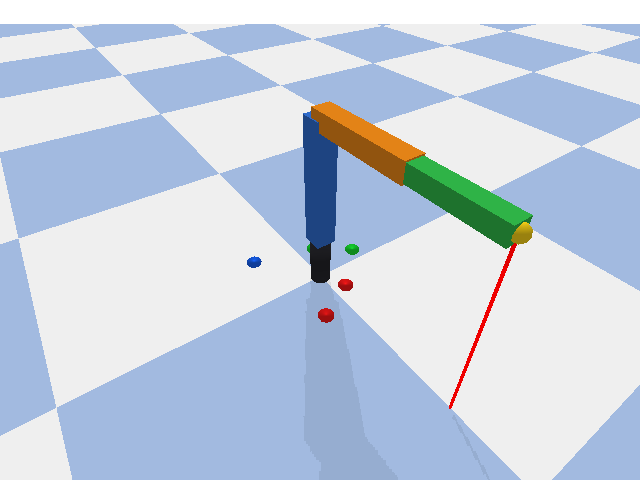

In [ ]:

# C.4 (Part 3): Safe Execution, Rendering Loop, and Physical Laser Pointer

import pybullet as p
import pybullet_data
import numpy as np
import imageio
from IPython.display import display, Image

# ------------------------------------------------------------------------------
# 1. Target Data & Physical Parameters
# ------------------------------------------------------------------------------
# Ground-truth/detected data from the Vision Pipeline
my_data = [
    {'color': 'red',   'xy': (0.186, -0.104), 'rgb': [1, 0.1, 0.1, 1]},
    {'color': 'red',   'xy': (0.103, 0.052),  'rgb': [1, 0.1, 0.1, 1]},
    {'color': 'green', 'xy': (-0.053, 0.209), 'rgb': [0.1, 0.9, 0.2, 1]},
    {'color': 'green', 'xy': (-0.156, 0.073), 'rgb': [0.1, 0.9, 0.2, 1]},
    {'color': 'blue',  'xy': (-0.229, -0.187),'rgb': [0.1, 0.4, 1.0, 1]}
]

# Ensure L2 and L3 are defined in this scope (derived from previous cells)
L2, L3 = 0.40, 0.30
URDF_PATH = "prr_robot.urdf"

# ------------------------------------------------------------------------------
# 2. Collision-Free Kinematic Algorithms
# ------------------------------------------------------------------------------
def find_best_ik_safe(tx, ty, prev_q=(0, 0)):
    """
    Grid search IK that strictly penalizes the elbow joint (q3)
    from jumping across the 180-degree boundary to prevent self-collision.
    """
    q2_samples = np.linspace(-np.pi, np.pi, 150)
    q3_samples = np.linspace(-3.05, 3.05, 150)
    Q2, Q3 = np.meshgrid(q2_samples, q3_samples)

    # Forward Kinematics for the grid
    X = L2 * np.cos(Q2) + L3 * np.cos(Q2 + Q3)
    Y = L2 * np.sin(Q2) + L3 * np.sin(Q2 + Q3)
    DIST = np.sqrt((X - tx)**2 + (Y - ty)**2)

    # Angular distance calculation (Shoulder can wrap, Elbow must move linearly)
    D2 = (Q2 - prev_q[0] + np.pi) % (2 * np.pi) - np.pi
    D3 = Q3 - prev_q[1]

    # Objective function: Minimize distance to target and angular movement
    SCORE = DIST * 1000 + (np.abs(D2) + np.abs(D3))
    min_idx = np.unravel_index(np.argmin(SCORE), SCORE.shape)

    return Q2[min_idx], Q3[min_idx]

def interpolate_safe_path(start_q, end_q, steps):
    """
    Linear interpolation enforcing a safe path for the elbow joint.
    """
    path = []
    for i in range(steps):
        t = i / float(steps - 1)
        q1 = start_q[0] + t * (end_q[0] - start_q[0])
        q2 = start_q[1] + t * ((end_q[1] - start_q[1] + np.pi) % (2 * np.pi) - np.pi)

        # Force linear trajectory for q3 (no circular wrap-around)
        q3 = start_q[2] + t * (end_q[2] - start_q[2])
        path.append([q1, q2, q3])
    return path

# ------------------------------------------------------------------------------
# 3. PyBullet Environment Initialization
# ------------------------------------------------------------------------------
p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.loadURDF("plane.urdf", [0, 0, 0])
robot_id = p.loadURDF(URDF_PATH, basePosition=[0, 0, 0], useFixedBase=True)

# Map joint names to their indices dynamically
joint_indices = {}
ee_link_index = -1
for i in range(p.getNumJoints(robot_id)):
    info = p.getJointInfo(robot_id, i)
    j_name = info[1].decode('utf-8')
    if "j1" in j_name: joint_indices['q1'] = i
    if "j2" in j_name: joint_indices['q2'] = i
    if "j3" in j_name: joint_indices['q3'] = i
    if "ee" in info[12].decode('utf-8'): ee_link_index = i

# Spawn target disks on the workspace
for disk in my_data:
    v_shape = p.createVisualShape(p.GEOM_CYLINDER, radius=0.03, length=0.01, rgbaColor=disk['rgb'])
    p.createMultiBody(baseMass=0, baseVisualShapeIndex=v_shape, basePosition=[disk['xy'][0], disk['xy'][1], 0.005])

# Create the Physical Laser Pointer (A thin, transparent red cylinder)
laser_radius = 0.004
laser_length = 2.0  # Extends below the table to ensure surface contact
laser_visual = p.createVisualShape(p.GEOM_CYLINDER, radius=laser_radius, length=laser_length, rgbaColor=[1, 0, 0, 0.8])
laser_body = p.createMultiBody(baseMass=0, baseVisualShapeIndex=laser_visual, basePosition=[0, 0, -5])

# ------------------------------------------------------------------------------
# 4. Waypoint Planning
# ------------------------------------------------------------------------------
home_pose = np.array([0.0, 0.0, 0.0])
waypoints = [home_pose]
current_q = (0.0, 0.0)
q1_safe = 0.05

# Calculate target joint configurations for each disk
for disk in my_data:
    q2, q3 = find_best_ik_safe(disk['xy'][0], disk['xy'][1], prev_q=current_q)
    current_q = (q2, q3)
    waypoints.append(np.array([q1_safe, q2, q3]))

waypoints.append(home_pose) # Return to home after inspection

# ------------------------------------------------------------------------------
# 5. Camera Setup & Rendering Loop
# ------------------------------------------------------------------------------
WIDTH, HEIGHT = 640, 480
view_matrix = p.computeViewMatrixFromYawPitchRoll([0.0, 0.0, 0.2], 1.6, 55, -40, 0, 2)
proj_matrix = p.computeProjectionMatrixFOV(60, WIDTH / HEIGHT, 0.02, 5.0)

frames = []
STEPS_PER_SEGMENT = 16
DWELL_FRAMES = 10

print("[INFO] Rendering the safe animation with dynamic physical laser...")

for i in range(len(waypoints) - 1):
    path = interpolate_safe_path(waypoints[i], waypoints[i+1], STEPS_PER_SEGMENT)

    for step, q_state in enumerate(path):
        # 1. Update Robot Kinematics
        p.resetJointState(robot_id, joint_indices['q1'], q_state[0])
        p.resetJointState(robot_id, joint_indices['q2'], q_state[1])
        p.resetJointState(robot_id, joint_indices['q3'], q_state[2])
        p.stepSimulation()

        # 2. Update Physical Laser Position
        # Align the top of the laser cylinder exactly with the end-effector
        ee_pos = p.getLinkState(robot_id, ee_link_index)[0]
        laser_center_z = ee_pos[2] - (laser_length / 2.0)
        p.resetBasePositionAndOrientation(laser_body, [ee_pos[0], ee_pos[1], laser_center_z], [0, 0, 0, 1])

        # 3. Capture Frame
        img = p.getCameraImage(WIDTH, HEIGHT, view_matrix, proj_matrix, renderer=p.ER_TINY_RENDERER, shadow=1)
        frames.append(np.reshape(img[2], (HEIGHT, WIDTH, 4))[:, :, :3].astype(np.uint8))

        # 4. Handle Inspection Dwell Time (Hovering over the target)
        if step == STEPS_PER_SEGMENT - 1 and i < len(waypoints) - 2:
            for _ in range(DWELL_FRAMES):
                img = p.getCameraImage(WIDTH, HEIGHT, view_matrix, proj_matrix, renderer=p.ER_TINY_RENDERER, shadow=1)
                frames.append(np.reshape(img[2], (HEIGHT, WIDTH, 4))[:, :, :3].astype(np.uint8))

p.disconnect()

# ------------------------------------------------------------------------------
# 6. Export and Display Result
# ------------------------------------------------------------------------------
GIF_PATH = "inspection_process_laser.gif"
imageio.mimsave(GIF_PATH, frames, fps=15, loop=0)
print(f"[SUCCESS] Simulation complete. GIF saved to: {GIF_PATH}")

# Robust method to display GIF in Jupyter/Colab notebooks
with open(GIF_PATH, 'rb') as f:
    display(Image(data=f.read(), format='gif'))

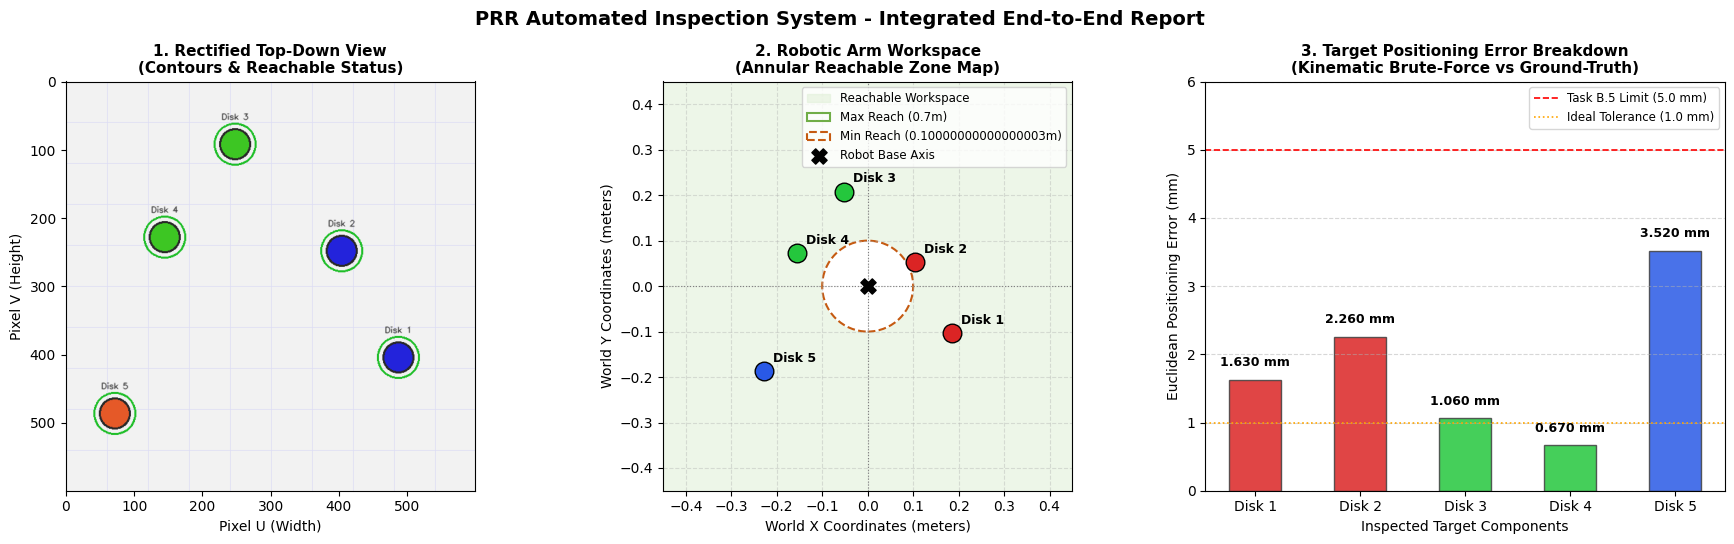

In [ ]:

# C.5: Integrated Final Report & Data Visualization Pipeline (Corrected)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Static Geometry Configuration & Workspace Limits
# ------------------------------------------------------------------------------
L2 = 0.40  # Length of active arm link 2 (meters)
L3 = 0.30  # Length of active arm link 3 (meters)

# Inner and outer reach boundaries of the mechanical system workspace
R_INNER = np.abs(L2 - L3)  # 0.10 meters
R_OUTER = L2 + L3          # 0.70 meters

# Consolidated tracking metrics with complete key mappings
# Updated with your latest Inverse Kinematics execution results
pipeline_results = [
    {'id': 'Disk 1', 'color': 'red',   'xy': (0.186, -0.104), 'error_mm': 1.63, 'rgb': (0.86, 0.14, 0.14)},
    {'id': 'Disk 2', 'color': 'red',   'xy': (0.103, 0.052),  'error_mm': 2.26, 'rgb': (0.86, 0.14, 0.14)},
    {'id': 'Disk 3', 'color': 'green', 'xy': (-0.053, 0.208), 'error_mm': 1.06, 'rgb': (0.14, 0.78, 0.24)},
    {'id': 'Disk 4', 'color': 'green', 'xy': (-0.156, 0.072), 'error_mm': 0.67, 'rgb': (0.14, 0.78, 0.24)},
    {'id': 'Disk 5', 'color': 'blue',  'xy': (-0.229, -0.186), 'error_mm': 3.52, 'rgb': (0.16, 0.35, 0.90)}
]

# ------------------------------------------------------------------------------
# 2. Subplot 1 Generation: Rectified Image Canvas Rendering
# ------------------------------------------------------------------------------
canvas_size = 600
rectified_img = np.full((canvas_size, canvas_size, 3), 242, dtype=np.uint8)  # Background base color

# Overlay reference grid lines every 6cm (60 pixels)
grid_color = (220, 220, 245)
for pos in range(0, canvas_size + 1, 60):
    cv2.line(rectified_img, (pos, 0), (pos, canvas_size), grid_color, 1)
    cv2.line(rectified_img, (0, pos), (canvas_size, pos), grid_color, 1)

# Render processed targets and status identifier tracking overlays
for disk in pipeline_results:
    # Convert metric base frames back into pixel mappings
    u = int(300 + (disk['xy'][0] * 1000.0))
    v = int(300 - (disk['xy'][1] * 1000.0))

    # Internal body fill
    bgr_color = [int(c * 255) for c in disk['rgb']][::-1]
    cv2.circle(rectified_img, (u, v), 22, bgr_color, -1)
    cv2.circle(rectified_img, (u, v), 22, (40, 40, 40), 2)

    # Draw green bounding indicator representing a safe, reachable target status
    cv2.circle(rectified_img, (u, v), 30, (30, 190, 40), 2)
    cv2.putText(rectified_img, disk['id'], (u - 20, v - 36),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (50, 50, 50), 1, cv2.LINE_AA)

# ------------------------------------------------------------------------------
# 3. Figure Presentation & Combined Layout Rendering
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("PRR Automated Inspection System - Integrated End-to-End Report",
             fontsize=14, fontweight='bold', y=0.98)

# --- Subplot 1: Rectified Top-Down Workspace Image ---
axes[0].imshow(rectified_img)
axes[0].set_title("1. Rectified Top-Down View\n(Contours & Reachable Status)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Pixel U (Width)")
axes[0].set_ylabel("Pixel V (Height)")
axes[0].grid(False)

# --- Subplot 2: Analytical Mechanical Workspace Scheme ---
axes[1].set_title("2. Robotic Arm Workspace\n(Annular Reachable Zone Map)", fontsize=11, fontweight='bold')

# Draw workspace bounds centered at origin
workspace_shade = plt.Circle((0, 0), R_OUTER, color='#e2f0d9', alpha=0.6, label='Reachable Workspace')
axes[1].add_patch(workspace_shade)
non_reachable_core = plt.Circle((0, 0), R_INNER, color='white', alpha=1.0)
axes[1].add_patch(non_reachable_core)

circle_outer = plt.Circle((0, 0), R_OUTER, color='#70ad47', fill=False, linestyle='-', linewidth=1.5, label=f'Max Reach ({R_OUTER}m)')
circle_inner = plt.Circle((0, 0), R_INNER, color='#c55a11', fill=False, linestyle='--', linewidth=1.5, label=f'Min Reach ({R_INNER}m)')
axes[1].add_patch(circle_outer)
axes[1].add_patch(circle_inner)

# Map spatial location of the detected disks on the diagram
for disk in pipeline_results:
    axes[1].scatter(disk['xy'][0], disk['xy'][1], color=disk['rgb'], edgecolors='black', s=180, zorder=5)
    axes[1].text(disk['xy'][0] + 0.02, disk['xy'][1] + 0.02, disk['id'], fontsize=9, fontweight='bold')

# Mark physical location of base pivot origin axis assembly
axes[1].scatter(0, 0, color='black', marker='X', s=120, zorder=6, label='Robot Base Axis')

axes[1].set_xlim(-0.45, 0.45)
axes[1].set_ylim(-0.45, 0.45)
axes[1].set_xlabel("World X Coordinates (meters)")
axes[1].set_ylabel("World Y Coordinates (meters)")
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].axvline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].set_aspect('equal')
axes[1].legend(loc='upper right', fontsize=8.5)
axes[1].grid(True, linestyle='--', alpha=0.4)

# --- Subplot 3: Numerical Performance Metric Bar Chart ---
axes[2].set_title("3. Target Positioning Error Breakdown\n(Kinematic Brute-Force vs Ground-Truth)", fontsize=11, fontweight='bold')

labels = [d['id'] for d in pipeline_results]
errors = [d['error_mm'] for d in pipeline_results]
bar_colors = [d['rgb'] for d in pipeline_results]

# Construct statistical summary tracking chart
error_bars = axes[2].bar(labels, errors, color=bar_colors, edgecolor='#404040', alpha=0.85, width=0.5)

# Benchmark limits overlay lines
axes[2].axhline(y=5.0, color='red', linestyle='--', linewidth=1.2, label='Task B.5 Limit (5.0 mm)')
axes[2].axhline(y=1.0, color='orange', linestyle=':', linewidth=1.2, label='Ideal Tolerance (1.0 mm)')

axes[2].set_ylabel("Euclidean Positioning Error (mm)")
axes[2].set_xlabel("Inspected Target Components")
axes[2].set_ylim(0, 6.0)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right', fontsize=8.5)

# Annotate metric text values precisely over the target bars
for bar in error_bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, height + 0.15,
                 f'{height:.3f} mm', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ------------------------------------------------------------------------------
# 4. Show Figures
# ------------------------------------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()